In [1]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
plt.rc('font', size=12.0)

In [46]:
models = ['mp']
x_name = ['a', 'alpha', 'param_S', 'param_L', '', 'trans1', '', 
           'trans2', '']
for k in range(len(models)):
    if models[k] == 'mp' or models[k] == 'np':
        x_name[4], x_name[6], x_name[8] = 'exp1', 'exp2', 'exp3'
    else:
        x_name[4], x_name[6], x_name[8] = 'csq1', 'csq2', 'csq3'
x_name = x_name + ['M_chirp_det', 'q']
y_name = [f"R_{i}" for i in range(100)]
y_name = y_name + ['M_max', 'dpdM', 'I1', 'I2']

dir = '/home/anik/bamr/out/aff_inv/'
mchain = h5py.File(dir + models[0] + '_all', 'r')['markov_chain_0']
nrow, data = mchain['nlines'][0], mchain['data']

x_ncol, y_ncol = len(x_name), len(y_name)
x, y = np.zeros((x_ncol, nrow)), np.zeros((y_ncol, nrow))

for i in range(x_ncol):
    x[i] = np.array(data[x_name[i]])
for i in range(y_ncol):
    if y_name[i] == 'M_max':
        y[i] = np.array(data[y_name[i]])*100
    else:
        y[i] = np.array(data[y_name[i]])

x, y = x.T, y.T
x_tr, x_ts, y_tr, y_ts = train_test_split(x, y, test_size=0.1, random_state=42)

In [30]:
DTR = DecisionTreeRegressor(criterion='absolute_error', random_state=42)
RFR = RandomForestRegressor(criterion='squared_error', random_state=42)
scoring = 'explained_variance'
cv, n_jobs = 10, -1
hp_dtr = {
    'max_depth': [16, 18, 20],
    'min_samples_leaf': [10, 12, 14],
    'min_samples_split': [2],
}

gs_dtr = GridSearchCV(estimator=DTR, param_grid=hp_dtr,
                      scoring=scoring, cv=cv, n_jobs=n_jobs,
                      return_train_score=True, verbose=2)
gs_dtr.fit(x_tr, y_tr)

Fitting 10 folds for each of 9 candidates, totalling 90 fits
[CV] END max_depth=16, min_samples_leaf=14, min_samples_split=2; total time= 2.3min
[CV] END max_depth=16, min_samples_leaf=14, min_samples_split=2; total time= 2.3min
[CV] END max_depth=16, min_samples_leaf=14, min_samples_split=2; total time= 2.3min
[CV] END max_depth=16, min_samples_leaf=12, min_samples_split=2; total time= 2.3min
[CV] END max_depth=16, min_samples_leaf=10, min_samples_split=2; total time= 2.3min
[CV] END max_depth=16, min_samples_leaf=14, min_samples_split=2; total time= 2.4min
[CV] END max_depth=16, min_samples_leaf=10, min_samples_split=2; total time= 2.4min
[CV] END max_depth=16, min_samples_leaf=10, min_samples_split=2; total time= 2.4min
[CV] END max_depth=16, min_samples_leaf=10, min_samples_split=2; total time= 2.4min
[CV] END max_depth=16, min_samples_leaf=10, min_samples_split=2; total time= 2.4min
[CV] END max_depth=16, min_samples_leaf=12, min_samples_split=2; total time= 2.4min
[CV] END max_de

GridSearchCV(cv=10,
             estimator=DecisionTreeRegressor(criterion='absolute_error',
                                             random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [16, 18, 20],
                         'min_samples_leaf': [10, 12, 14],
                         'min_samples_split': [2]},
             return_train_score=True, scoring='explained_variance', verbose=2)

In [33]:
best_dtr = gs_dtr.best_estimator_
best_hps = gs_dtr.best_params_
print(f"Best HPs for DTR-1: {best_hps}")
y_pr = best_dtr.predict(x_ts)
mse = mean_squared_error(y_ts, y_pr)
mae = mean_absolute_error(y_ts, y_pr)
r2 = r2_score(y_ts, y_pr)
print(f"MSE: {mse}, MAE: {mae}, R2: {r2}")

Best HPs for DTR-1: {'max_depth': 18, 'min_samples_leaf': 12, 'min_samples_split': 2}
MSE: 438654197685267.9, MAE: 794454.1619344613, R2: 0.4025110401097733


In [50]:
DTR = DecisionTreeRegressor(#max_depth=18, min_samples_leaf=12, min_samples_split=2, 
                            criterion='absolute_error', random_state=42)
DTR.fit(x_tr, y_tr)
y_pr = DTR.predict(x_tr)
mse = mean_squared_error(y_tr, y_pr)
mae = mean_absolute_error(y_tr, y_pr)
r2 = r2_score(y_tr, y_pr)
print(f"DTR: mse={mse}, mae={mae}, r2={r2}")

DTR: mse=4.4622520185211676e-18, mae=7.461561992861051e-12, r2=1.0


In [ ]:
#from scipy.interpolate import interp1d

# Assuming y_pr is already defined
rd = y_pr[:, 0:100]  # Step 1: Get the first 100 columns
m_max = y_pr[:, 100]  # Step 2: Get the 101st column

# Step 3: Create gm and find the index of the first element in gm greater than m_max[i]
gm = np.linspace(0.2, 3.0, 100)
i_max = np.array([np.where(gm > m_max[i])[0][0] for i in range(len(m_max))])

# Initialize r_max to store results
r_max = np.zeros_like(m_max)

# Step 4-7: Loop through each row
for i in range(y_pr.shape[0]):
    # Step 5: m contains the first i_max[i] elements of gm
    m = gm[:i_max[i]]
    
    # Step 6: r contains the first len(m) elements of rd[i], which are all nonzeros
    r = rd[i][:len(m)]
    
    # Step 7: Linearly extrapolate r_max[i] from the m-r curve
    r_max[i] = np.interp(m_max[i], m, r)

# r_max now contains the extrapolated values
print(r_max)

plt.plot(r_max)
plt.show()

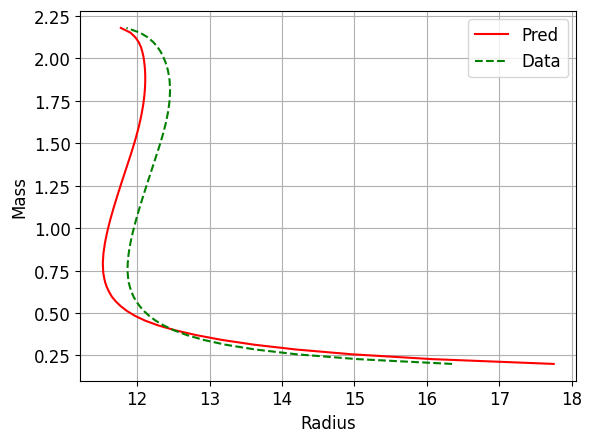

In [48]:
# Get rd and m_max
y_pr = DTR.predict(x_ts)
rd = y_pr[:, 0:100]
rd2 = y_ts[:, 0:100]
m_max = y_pr[:, 100]/100
m_max2 = y_ts[:, 100]/100
gm = np.linspace(0.2, 3.0, 100)
# Find i_max
i_max = np.array([np.where(gm > m_max[i])[0][0] for i in range(len(m_max))])
i_max2 = np.array([np.where(gm > m_max2[i])[0][0] for i in range(len(m_max2))])

# Select a random row index
random_index = np.random.randint(0, y_pr.shape[0])

# Extract m and r for the selected row
m = gm[:i_max[random_index]]
m2 = gm[:i_max2[random_index]]
r = rd[random_index][:len(m)]
r2 = rd2[random_index][:len(m2)]

# Plot m against r
plt.plot(r, m, label='Pred', c='r')
plt.plot(r2, m2, label='Data', c='g', ls='--')
plt.xlabel('Radius')
plt.ylabel('Mass')
plt.grid(True)
plt.legend()
plt.show()

In [175]:
n_good=0
for i in range(m_max.shape[0]):
    if 1- np.abs(m_max[i] - m_max2[i])/m_max2[i] >= 0.95:
        n_good+=1
print(n_good,'/',m_max.shape[0])
#plt.xlabel('n_samples')
#plt.ylabel('M_max error (%)')
#plt.show()

0 0.0
1 0.0
2 0.0
3 0.0
4 0.0
5 0.0
6 0.0
7 0.0
8 0.0
9 0.0
10 0.0
11 0.0
12 0.0
13 0.0
14 0.0
15 0.0
16 0.0
17 0.0
18 0.0
19 0.0
20 0.0
21 0.0
22 0.0
23 0.0
24 0.0
25 0.0
26 0.0
27 0.0
28 0.0
29 1.2030565309006052e-10
30 0.0
31 0.0
32 0.0
33 0.0
34 0.0
35 0.0
36 0.0
37 0.0
38 0.0
39 0.0
40 0.0
41 0.0
42 0.0
43 0.0
44 0.0
45 0.0
46 0.0
47 0.0
48 0.0
49 0.0
50 0.0
51 0.0
52 0.0
53 4.199844494622672e-11
54 0.0
55 1.2190207089981042e-09
56 0.0
57 0.0
58 0.0
59 0.0
60 0.0
61 0.0
62 0.0
63 0.0
64 0.0
65 0.0
66 0.0
67 0.0
68 0.0
69 0.0
70 0.0
71 0.0
72 0.0
73 0.0
74 0.0
75 0.0
76 0.0
77 0.0
78 0.0
79 0.0
80 0.0
81 0.0
82 0.0
83 0.0
84 0.0
85 0.0
86 0.0
87 0.0
88 0.0
89 0.0
90 0.0
91 0.0
92 0.0
93 0.0
94 0.0
95 0.0
96 0.0
97 0.0
98 0.0
99 0.0
100 0.0
101 0.0
102 0.0
103 1.740506727919305e-10
104 0.0
105 0.0
106 0.0
107 0.0
108 0.0
109 0.0
110 0.0
111 0.0
112 0.0
113 0.0
114 0.0
115 0.0
116 0.0
117 0.0
118 0.0
119 0.0
120 0.0
121 0.0
122 0.0
123 0.0
124 0.0
125 0.0
126 0.0
127 0.0
128 0.0
129 

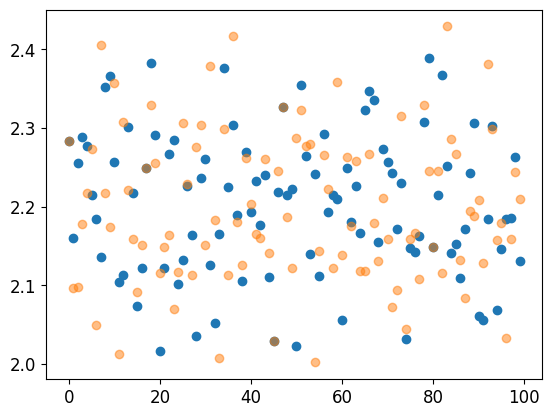

In [41]:
i = np.arange(100)
plt.scatter(i, m_max[:100])
plt.scatter(i, m_max2[:100], alpha=0.5)

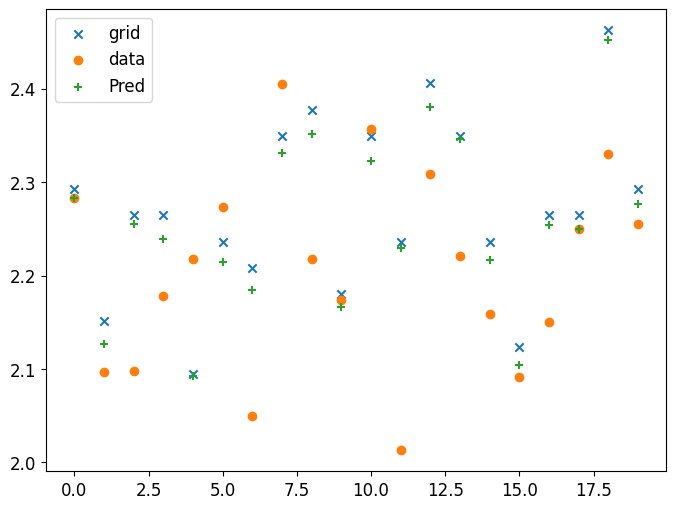

In [49]:
i_max=[]
for i in range(rd.shape[0]):
    i_max.append(np.where(rd[i] > 0)[0][-1])
i_max = np.array(i_max) + 1
m_max = gm[i_max]
m_max2 = y_ts[:, 100]/100
m_max3 = y_pr[:, 100]/100
plt.figure(figsize=(8, 6))
plt.scatter(np.arange(0,20,1),  m_max[:20], marker='x', label='grid')
plt.scatter(np.arange(0,20,1), m_max2[:20], marker='o', label='data')
plt.scatter(np.arange(0,20,1), m_max3[:20], marker='+', label='Pred')
plt.legend()
plt.show()